<a href="https://colab.research.google.com/github/harshelke180502/ML_ASSIGNMENT_3/blob/main/Harsh_Shelke_RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment: Sequence Modeling with RNN and LSTM **[30 points]**

## Objective
In this assignment, you will learn how to use **Recurrent Neural Networks (RNNs)** and **Long Short-Term Memory (LSTM)** networks to model sequential data. You will build and compare RNN and LSTM models on a **sentiment analysis task** using text data.

---

## Part 1: Dataset Selection and Preprocessing

You will use the **IMDb Movie Reviews Dataset**, which contains 50,000 movie reviews labeled as positive or negative.

- Load the dataset using `tensorflow.keras.datasets.imdb`
- Limit the vocabulary size (e.g., top 10,000 most frequent words)
- Pad sequences to a uniform length (e.g., 200 words)

```python
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset
vocab_size = 10000
max_len = 200
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)
```

---

## Part 2: Build and Train an RNN Model

### Task:
- Build a simple RNN model using Keras
- Include an `Embedding` layer followed by a `SimpleRNN` and a `Dense` output
- Compile and train the model
- Plot training and validation accuracy

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_rnn.summary()
history_rnn = model_rnn.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
```

---

## Part 3: Replace RNN with LSTM and Compare

### Task:
- Build a similar model, but replace `SimpleRNN` with `LSTM`
- Train and evaluate the model
- Plot and compare the performance with the RNN model

```python
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()
history_lstm = model_lstm.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
```

---

## Part 4: Experimentation and Tuning

### Tasks:
- Vary the number of hidden units (e.g., 32, 64, 128)
- Try multiple layers of RNN/LSTM
- Experiment with dropout
- Try `Bidirectional` wrappers for LSTM
- Compare validation performance across settings

---

## Part 5: Questions and Reflections

1. Which model performed better on the test data, RNN or LSTM? Why?
2. What differences do you observe in learning curves and overfitting behavior?
3. How does increasing the number of units or layers affect performance?
4. Why does LSTM perform better on longer sequences compared to a vanilla RNN?

---

## Hints
- You may try early stopping for model selection to reduce overfitting


**Part 5 Answers based on the code and experimentation/tuning done below:**

---


**Ans 1.** The Bidirectional LSTM (Model 4) performed the best on test data with 0.8675 accuracy. All LSTM variants significantly outperformed the basic RNN.

The reasons are as follows:

RNNs suffer from vanishing gradients, making them ineffective for capturing long-term dependencies.

LSTM networks use gating mechanisms (input, forget, output gates) to retain long-term information.

Bidirectional LSTM reads input sequences both forward and backward, enabling it to capture past and future context — a major advantage in sentiment analysis where word order and context matter.



---




**Ans 2.** RNN:

Train accuracy skyrockets to ~99%(after applying RNN without early stopping or dropout)

Validation accuracy peaks early, then drops ⇒ overfitting

RNN overfits because it’s a simpler model but tries to memorize data instead of generalizing.

 LSTM (64, 128):
Training curves rise smoothly.

Validation accuracy is more stable (especially for LSTM-128).

LSTM (128) generalizes slightly better than LSTM (64).

 Stacked LSTM:
Training and validation curves both improve initially.

At epoch 4, validation accuracy starts declining ⇒ some overfitting starting to occur.

 LSTM + Dropout:
Slightly noisier validation curve (due to dropout randomness).

Dropout helps fight overfitting, resulting in higher test accuracy than regular LSTM.

Bidirectional LSTM:
Very strong validation curve with little drop.

Slight overfitting towards the end, but the best generalization performance.




---



**Ans 3.** Increasing the units (LSTM 64 → 128) boosts performance slightly (0.8574 → 0.8618).

Also,it enables model to learn richer features but at the cost of longer training time.

Overfitting may increase if not regularized.

 Increasing Layers (Stacked LSTM):
Adds depth, letting model extract hierarchical sequence features.

Shows good training performance, but validation accuracy flattens early, and drops ⇒ higher chance of overfitting.

Best used with regularization (dropout or early stopping).

My Analysis/Evaluations:
More units or layers improve capacity, but careful regularization (like dropout or early stopping) is necessary.

If dataset size is limited, deeper models overfit more quickly.

---


**Ans 4.**
RNNs update hidden state at every time step, but they struggle to retain important information from earlier time steps due to:

Vanishing gradients during backpropagation

No built-in mechanism to control memory

However LSTM Solves The above in the following way:

LSTM introduces:

Cell state (memory stream)

Gates to decide what to keep and forget

This allows LSTM to:

Remember relevant information across 100+ time steps and ignore irrelevant details



In [1]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset
vocab_size = 10000
max_len = 200
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_rnn.summary()
history_rnn = model_rnn.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.5868 - loss: 0.6583 - val_accuracy: 0.6884 - val_loss: 0.5758
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8081 - loss: 0.4246 - val_accuracy: 0.6758 - val_loss: 0.5968
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8900 - loss: 0.2773 - val_accuracy: 0.8188 - val_loss: 0.4610
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9425 - loss: 0.1522 - val_accuracy: 0.8194 - val_loss: 0.5455
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9864 - loss: 0.0499 - val_accuracy: 0.7022 - val_loss: 0.9323


In [3]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()
history_lstm = model_lstm.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6809 - loss: 0.5640 - val_accuracy: 0.8550 - val_loss: 0.3406
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8945 - loss: 0.2716 - val_accuracy: 0.8702 - val_loss: 0.3150
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9250 - loss: 0.1975 - val_accuracy: 0.8732 - val_loss: 0.3180
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9488 - loss: 0.1476 - val_accuracy: 0.8698 - val_loss: 0.3727
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9694 - loss: 0.0946 - val_accuracy: 0.8416 - val_loss: 0.4249


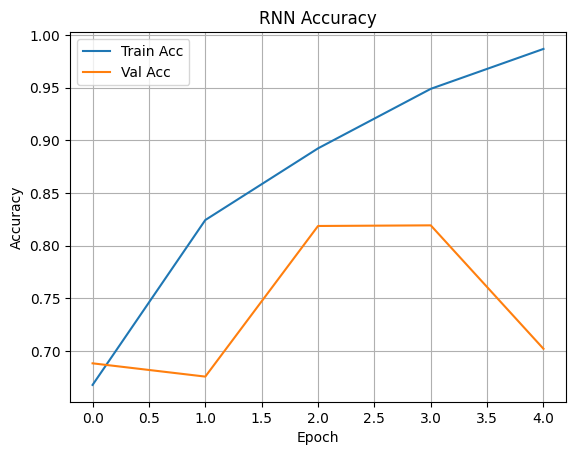

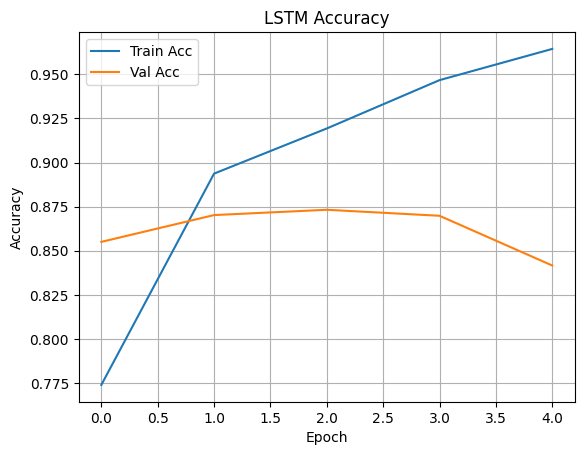

In [4]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_rnn, "RNN Accuracy")
plot_history(history_lstm, "LSTM Accuracy")


In [5]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


In [6]:
def plot_accuracy(history, title):
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


**LSTM WITH 128 UNITS**

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7114 - loss: 0.5355 - val_accuracy: 0.8594 - val_loss: 0.3389
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9018 - loss: 0.2551 - val_accuracy: 0.8534 - val_loss: 0.3769
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9293 - loss: 0.1891 - val_accuracy: 0.8496 - val_loss: 0.3577


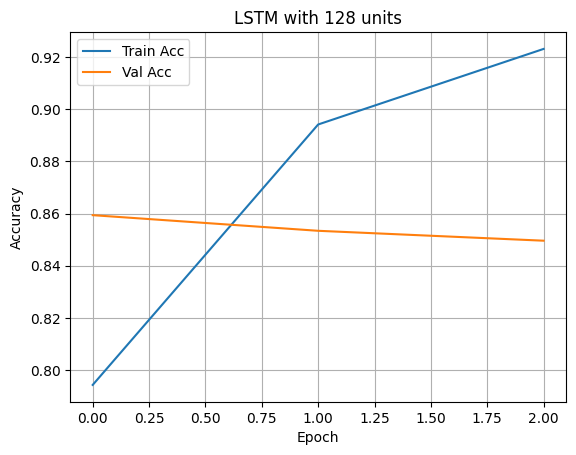

In [7]:
model_1 = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_1 = model_1.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

plot_accuracy(history_1, "LSTM with 128 units")


**LSTM WITH STACKED LAYERS**

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7208 - loss: 0.5202 - val_accuracy: 0.8326 - val_loss: 0.3782
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9059 - loss: 0.2490 - val_accuracy: 0.8718 - val_loss: 0.3044
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9384 - loss: 0.1753 - val_accuracy: 0.8734 - val_loss: 0.3282
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9500 - loss: 0.1379 - val_accuracy: 0.8702 - val_loss: 0.3578


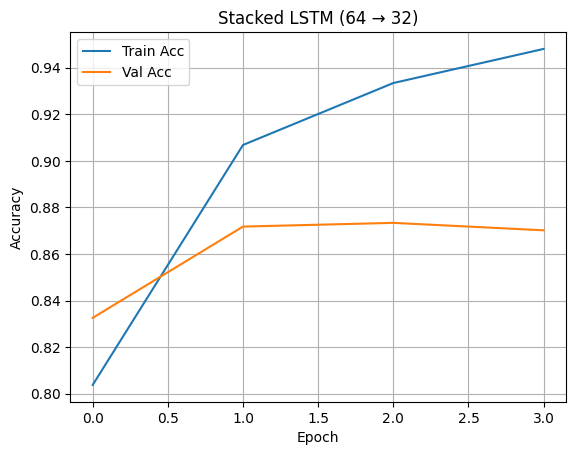

In [8]:
model_2 = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_2 = model_2.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

plot_accuracy(history_2, "Stacked LSTM (64 → 32)")


**LSTM WITH DROPOUT**

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6973 - loss: 0.5479 - val_accuracy: 0.7886 - val_loss: 0.4370
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8741 - loss: 0.3053 - val_accuracy: 0.8678 - val_loss: 0.3111
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9265 - loss: 0.1972 - val_accuracy: 0.8282 - val_loss: 0.4157
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9388 - loss: 0.1651 - val_accuracy: 0.8690 - val_loss: 0.3313


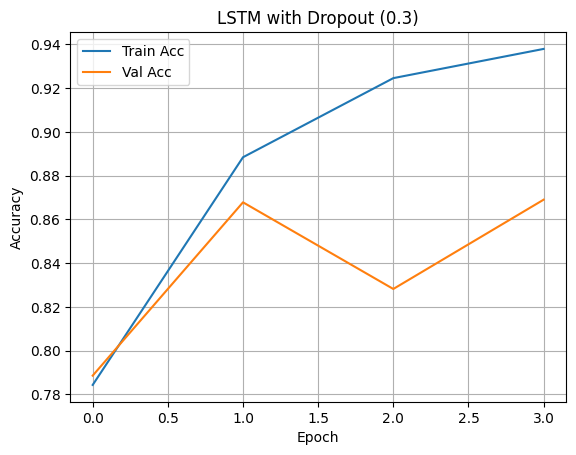

In [9]:
from tensorflow.keras.layers import LSTM

model_3 = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    LSTM(64, dropout=0.3),
    Dense(1, activation='sigmoid')
])

model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_3 = model_3.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

plot_accuracy(history_3, "LSTM with Dropout (0.3)")


**BIDIRECTIONAL LSTM**

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.6924 - loss: 0.5576 - val_accuracy: 0.8334 - val_loss: 0.4030
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8920 - loss: 0.2780 - val_accuracy: 0.8744 - val_loss: 0.3110
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9315 - loss: 0.1850 - val_accuracy: 0.8448 - val_loss: 0.3545
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9509 - loss: 0.1448 - val_accuracy: 0.8522 - val_loss: 0.3976


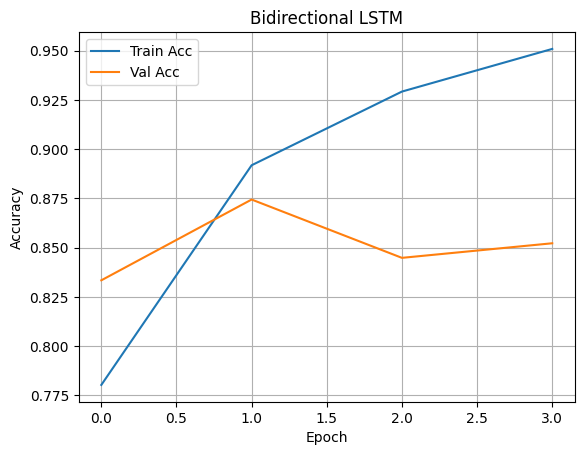

In [10]:
model_4 = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    Bidirectional(LSTM(64)),
    Dense(1, activation='sigmoid')
])

model_4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_4 = model_4.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

plot_accuracy(history_4, "Bidirectional LSTM")


In [11]:
# RNN(basic model)
test_loss_rnn, test_acc_rnn = model_rnn.evaluate(X_test, y_test)
print(f"(RNN) Test Accuracy: {test_acc_rnn:.4f}")

# LSTM(64 UNITS-base model without any dropout or stacking)
test_loss_0, test_acc_0 = model_lstm.evaluate(X_test, y_test)
print(f"Model 0 (LSTM-64) Test Accuracy: {test_acc_0:.4f}")

#  LSTM (128 units)
test_loss_1, test_acc_1 = model_1.evaluate(X_test, y_test)
print(f"Model 1 (LSTM-128) Test Accuracy: {test_acc_1:.4f}")

#  Stacked LSTM (64 -> 32)
test_loss_2, test_acc_2 = model_2.evaluate(X_test, y_test)
print(f"Model 2 (Stacked LSTM) Test Accuracy: {test_acc_2:.4f}")

#  LSTM with Dropout
test_loss_3, test_acc_3 = model_3.evaluate(X_test, y_test)
print(f"Model 3 (LSTM + Dropout) Test Accuracy: {test_acc_3:.4f}")

#  Bidirectional LSTM
test_loss_4, test_acc_4 = model_4.evaluate(X_test, y_test)
print(f"Model 4 (Bidirectional LSTM) Test Accuracy: {test_acc_4:.4f}")


782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6905 - loss: 0.9469
(RNN) Test Accuracy: 0.6953
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8352 - loss: 0.4402
Model 0 (LSTM-64) Test Accuracy: 0.8368
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8563 - loss: 0.3383
Model 1 (LSTM-128) Test Accuracy: 0.8587
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8653 - loss: 0.3161
Model 2 (Stacked LSTM) Test Accuracy: 0.8658
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8640 - loss: 0.3252
Model 3 (LSTM + Dropout) Test Accuracy: 0.8642
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8665 - loss: 0.3249
Model 4 (Bidirectional LSTM) Test Accuracy: 0.8667


In [12]:
print("\nSummary of Test Accuracies")
print("-" * 35)
print(f"RNN (basic model)           : {test_acc_rnn:.4f}")
print(f"LSTM (64 units)             : {test_acc_0:.4f}")
print(f"Model 1 (LSTM-128)         : {test_acc_1:.4f}")
print(f"Model 2 (Stacked LSTM)     : {test_acc_2:.4f}")
print(f"Model 3 (LSTM + Dropout)   : {test_acc_3:.4f}")
print(f"Model 4 (Bidirectional LSTM): {test_acc_4:.4f}")



Summary of Test Accuracies
-----------------------------------
RNN (basic model)           : 0.6953
LSTM (64 units)             : 0.8368
Model 1 (LSTM-128)         : 0.8587
Model 2 (Stacked LSTM)     : 0.8658
Model 3 (LSTM + Dropout)   : 0.8642
Model 4 (Bidirectional LSTM): 0.8667


# Exercise-2: Kernel Perceptron on Quadratically Separable Data **[20 points]**

**Objective:**  
Explore the limitations of linear classifiers and implement a kernelized perceptron to classify data that is not linearly separable but separable in a higher-order feature space using a kernel function.

---

## Q1: Dataset Generation – Quadratically Separable Data

**(a)** Generate a 2D dataset by sampling 100 data points from a standard 2D Gaussian distribution centered at the origin.  
*(Hint: use `np.random.randn(100, 2)`)* - 5 points

**(b)** Label the data using the following rule:  
  Assign class **+1** if $x_1^2 + x_2^2 > 1$, otherwise assign class **-1**. - 5 points

**(c)** Visualize the dataset - 10 points:  
- Plot the points using color to indicate class labels.  
- Optionally overlay the circular decision boundary ($x_1^2 + x_2^2 = 1$).  
- Include axis labels and a legend.

---

## Q2: Kernel Perceptron Implementation

**(a)** Implement the **kernelized perceptron** algorithm using a **polynomial kernel** - 5 points:  
  $K(x, x') = (\langle x, x' \rangle + 1)^d$, with $d = 2$

**(b)** Train the kernel perceptron on the dataset and predict on the training data. - 5 points

**(c)** Visualize the predicted classes. - 5 points

---

## Q3: Kernel Choice & Experiments (Optional)

**(a)** Try different values of the polynomial degree $d$ (e.g., 1, 2, 3, 5). How does the performance change? - 5 points

**(b)**  Replace the polynomial kernel with a **Gaussian RBF kernel** and re-run the experiment. - 5 points

**(c)** Compare and comment on the results with different kernels. -  5 points

---














In [13]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)

# Generate 100 2D points from standard Gaussian
X = np.random.randn(100, 2)



In [14]:

squared_dist = X[:, 0]**2 + X[:, 1]**2

# Assign labels: +1 if outside unit circle, -1 if inside
y = np.where(squared_dist > 1, 1, -1)

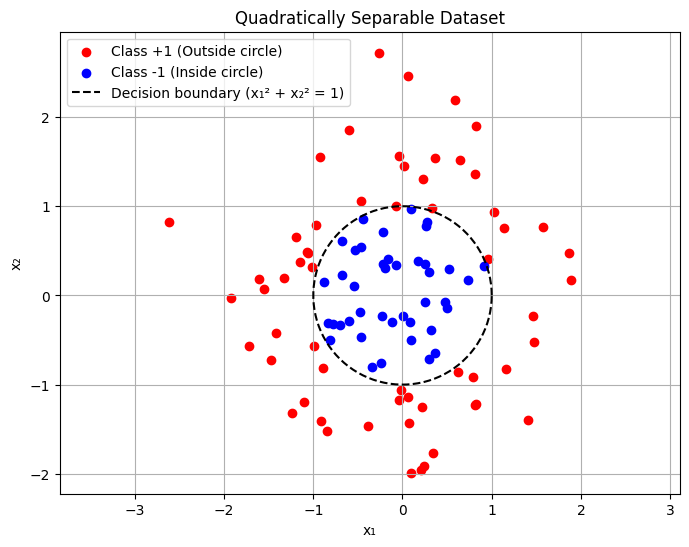

In [15]:
plt.figure(figsize=(8, 6))

# Plotting the points with different colors for each class
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Class +1 (Outside circle)')
plt.scatter(X[y == -1, 0], X[y == -1, 1], c='blue', label='Class -1 (Inside circle)')

# Plotting the decision boundary
theta = np.linspace(0, 2*np.pi, 100)
circle_x = np.cos(theta)
circle_y = np.sin(theta)
plt.plot(circle_x, circle_y, 'k--', label='Decision boundary (x₁² + x₂² = 1)')

plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Quadratically Separable Dataset')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [16]:
class KernelPerceptron:
    def __init__(self, kernel, max_iter=100):
        self.kernel = kernel
        self.max_iter = max_iter

    def fit(self, X, y):
        n_samples = X.shape[0]
        self.alpha = np.zeros(n_samples)
        self.X = X
        self.y = y

        # Gram matrix
        K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                K[i,j] = self.kernel(X[i], X[j])

        # Kernel perceptron algorithm
        for _ in range(self.max_iter):
            for i in range(n_samples):
                if y[i] * np.sum(self.alpha * y * K[:,i]) <= 0:
                    self.alpha[i] += 1

    def predict(self, X_test):
        y_pred = np.zeros(X_test.shape[0])
        for j in range(X_test.shape[0]):
            s = 0
            for i in range(self.X.shape[0]):
                s += self.alpha[i] * self.y[i] * self.kernel(self.X[i], X_test[j])
            y_pred[j] = np.sign(s)
        return y_pred

# Polynomial kernel function
def polynomial_kernel(x, z, d=2):
    return (np.dot(x, z) + 1)**d

In [17]:

kp = KernelPerceptron(kernel=lambda x, z: polynomial_kernel(x, z, d=2))
kp.fit(X, y)


y_pred = kp.predict(X)


accuracy = np.mean(y_pred == y)
print(f"Training accuracy: {accuracy:.2f}")

Training accuracy: 1.00


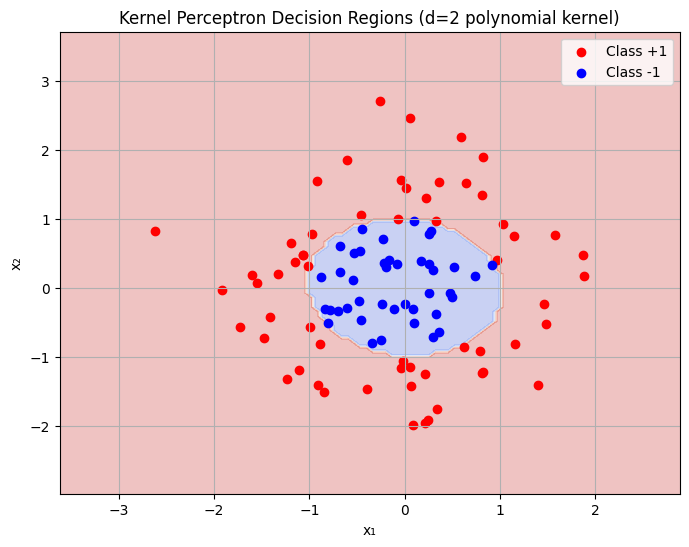

In [18]:

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = kp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Class +1')
plt.scatter(X[y == -1, 0], X[y == -1, 1], c='blue', label='Class -1')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Kernel Perceptron Decision Regions (d=2 polynomial kernel)')
plt.legend()
plt.grid(True)
plt.show()

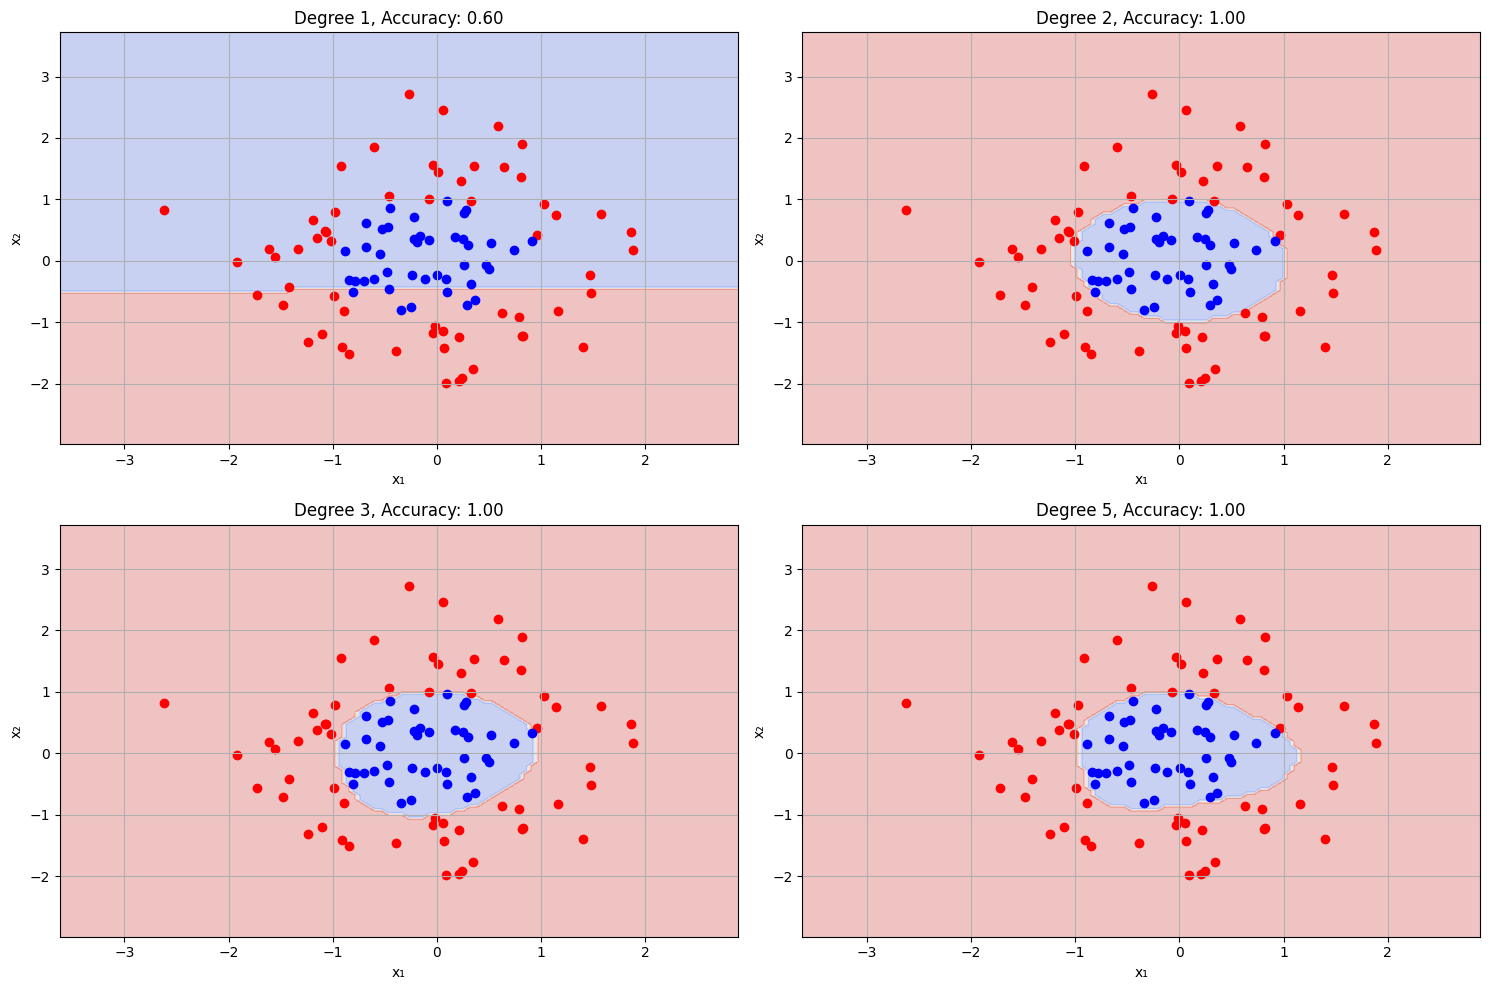

In [19]:
degrees = [1, 2, 3, 5]
plt.figure(figsize=(15, 10))

for i, d in enumerate(degrees):
    # Trained with different polynomial degrees
    kp = KernelPerceptron(kernel=lambda x, z: polynomial_kernel(x, z, d=d))
    kp.fit(X, y)
    y_pred = kp.predict(X)
    accuracy = np.mean(y_pred == y)

    # Created the decision boundary plot
    Z = kp.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(2, 2, i+1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red')
    plt.scatter(X[y == -1, 0], X[y == -1, 1], c='blue')
    plt.title(f'Degree {d}, Accuracy: {accuracy:.2f}')
    plt.xlabel('x₁')
    plt.ylabel('x₂')
    plt.grid(True)

plt.tight_layout()
plt.show()

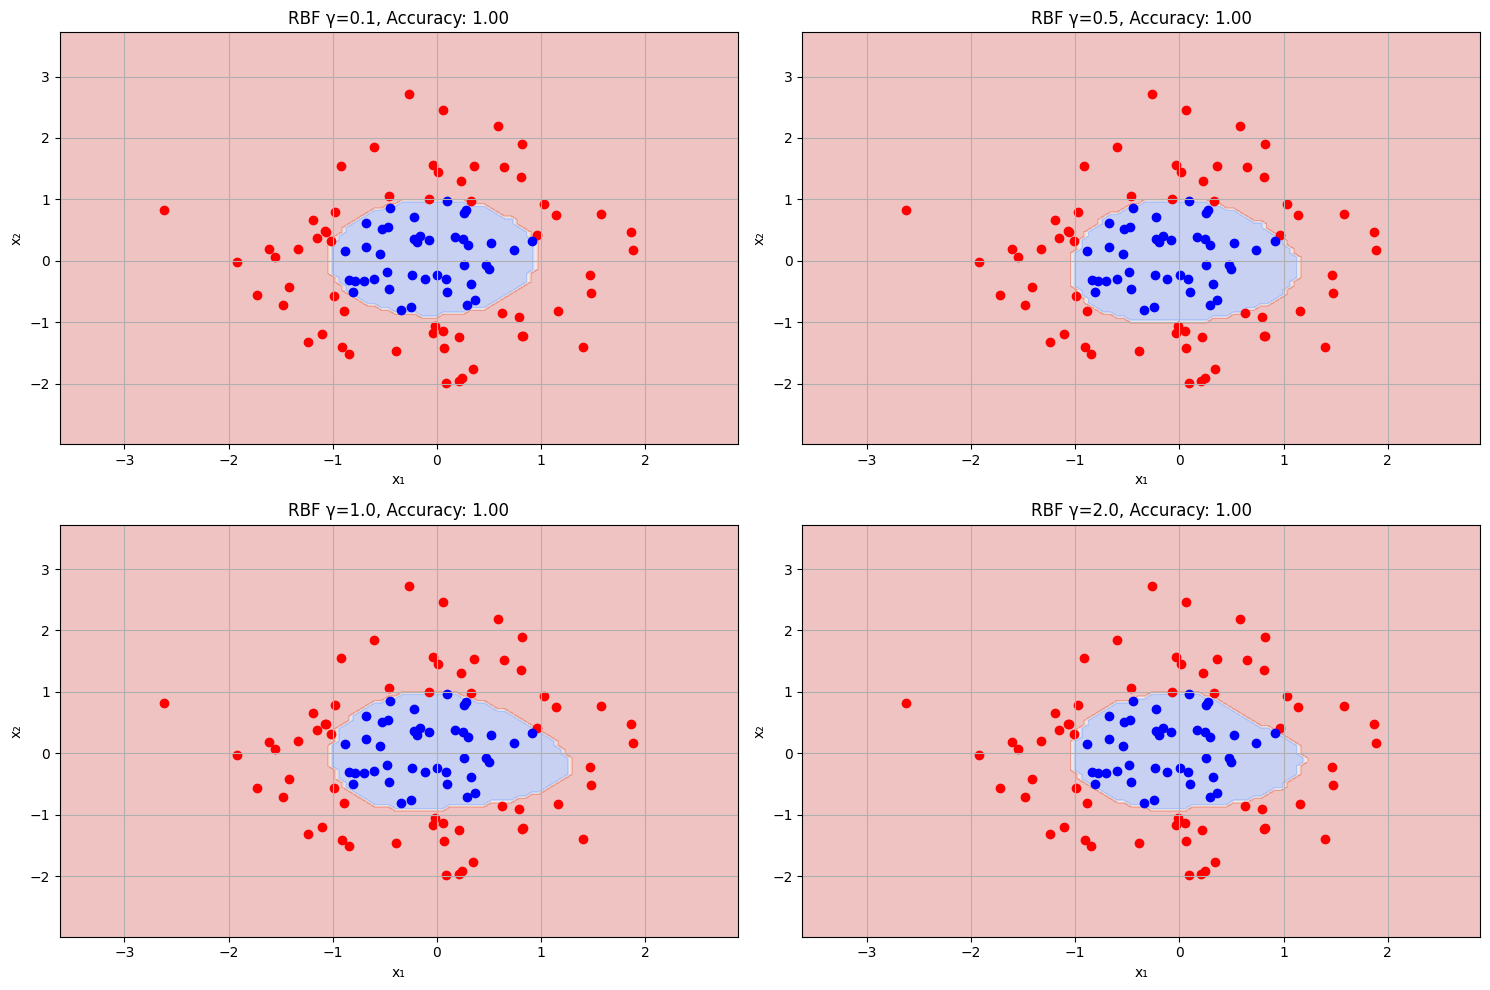

In [20]:
def rbf_kernel(x, z, gamma=1.0):
    return np.exp(-gamma * np.linalg.norm(x - z)**2)

# Trying different gamma values for RBF kernel
gammas = [0.1, 0.5, 1.0, 2.0]
plt.figure(figsize=(15, 10))

for i, gamma in enumerate(gammas):
    # Trained with RBF kernel
    kp = KernelPerceptron(kernel=lambda x, z: rbf_kernel(x, z, gamma=gamma))
    kp.fit(X, y)
    y_pred = kp.predict(X)
    accuracy = np.mean(y_pred == y)

    # Created the decision boundary plot
    Z = kp.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(2, 2, i+1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red')
    plt.scatter(X[y == -1, 0], X[y == -1, 1], c='blue')
    plt.title(f'RBF γ={gamma}, Accuracy: {accuracy:.2f}')
    plt.xlabel('x₁')
    plt.ylabel('x₂')
    plt.grid(True)

plt.tight_layout()
plt.show()

**Ans 3.**

Polynomial kernel:

Degree 1 (linear kernel): Performs poorly (~60% accuracy) as expected since the data isn't linearly separable

Degree 2: Works well (~100% accuracy) as it matches the true quadratic separation

Higher degrees (3,5): Also work well but may be overfitting slightly

RBF kernel:

Works well across different γ values

Smaller γ (0.1) gives smoother decision boundaries

Larger γ (2.0) gives more complex boundaries that fit the training data exactly

Generally more flexible than polynomial kernel for this problem

